In [ ]:
from experiments.ngram import build_table
from experiments.train import load_data, BASE_CONFIG, encode

In [7]:
data, vocab = load_data(BASE_CONFIG)

In [8]:
%%time 
pair_counts, context_counts = build_table(data['train'].tolist(), k = 0)

CPU times: user 182 ms, sys: 2.61 ms, total: 184 ms
Wall time: 183 ms


In [ ]:
from experiments.ngram import KneserNeyModel, BackoffModel

In [ ]:
train_ids, val_ids = data['train'].tolist(), data['val'].tolist()
V = len(vocab)
print(f'{len(train_ids)} train chars, {len(val_ids)} val chars, vocab {V}')
backoff = BackoffModel(train_ids, 7, V)
kn = KneserNeyModel(train_ids, 7, V)

892315 train chars, 223079 val chars, vocab 65


In [16]:
data, chars = load_data(BASE_CONFIG)
train_ids, val_ids = data['train'].tolist(), data['val'].tolist()
V = len(chars)
 

In [17]:
encode('abc', chars)

NameError: name 'encode' is not defined

In [15]:
encode('abc', vocab)

NameError: name 'encode' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.nn import functional as F
import torch
from collections import defaultdict

In [164]:
config = {
    'seq_len': 8,
    'batch_size': 4,
    'vocab_size': vocab_size,
    'dim_embed': 32,
    'eval_iters': 1000,
    'dim_hidden': 128,
    'num_iters': 5000,
    'print_every': 100,
    'test_ratio': 0.2,
    'lr': 0.001,
}

In [172]:
def train_test_split(data, test_ratio):
    split_idx = int(len(data) * (1 - test_ratio))
    train_data, val_data = data[:split_idx], data[split_idx:]
    return train_data, val_data

def create_data_dictionary(text):
    data = torch.tensor(encode(text), dtype=torch.long)
    train_data, test_data = train_test_split(data, test_ratio=0.2)
    return {
        'train': train_data,
        'val': test_data,
    }

def make_batch(data, config):
    seq_len, batch_size = config['seq_len'], config['batch_size']
    indices = np.random.randint(0, len(data) - seq_len, size=batch_size)
    X = torch.stack([data[i:i+seq_len] for i in indices])
    y = torch.stack([data[i+1:i+seq_len+1] for i in indices])
    return X, y

In [173]:
@torch.no_grad()
def estimate_loss(data, model, config):
    eval_iters = config['eval_iters']
    split_loss = {}
    model.eval() # In case the model has drop-out. 
    for split in ['train', 'val']:
        losses = []
        for _ in range(eval_iters):
            X, y = make_batch(data[split], config)
            _, loss = model(X, y)
            losses.append(loss)
        split_loss[split] = np.mean(losses)
    model.train()
    return split_loss

In [ ]:
class Model(nn.Module):
    def __init__(self, vocab_size, dim_embed, dim_hidden, seq_len):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, dim_embed)
        self.pos_embedding = nn.Embedding(seq_len, dim_embed)
        self.block = nn.Sequential(
            nn.Linear(dim_embed, dim_hidden),
            nn.ReLU(),
            nn.Linear(dim_hidden, vocab_size)
        )
    def forward(self, x, y=None):
        B, T = x.shape
        x = self.token_embedding(x)
        pos = self.pos_embedding(torch.arange(T))
        x = x + pos
        logits = self.block(x)
        if y is None:
            loss = None
        else:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), y.view(B * T))
        return logits, loss
    
    def generate(self, x, max_new_tokens):
        # Here X has shape (B, T , C)
        logits = self.forward(x[:, :-8])
        B, T, C = logits.shape
        logits, _ = F.softmax()
        torch.multinomial(


        



In [178]:
data = create_data_dictionary(text)
model = Model(config['vocab_size'], config['dim_embed'], config['dim_hidden'], config['seq_len'])
optim = torch.optim.Adam(params = model.parameters(), lr=config['lr'])


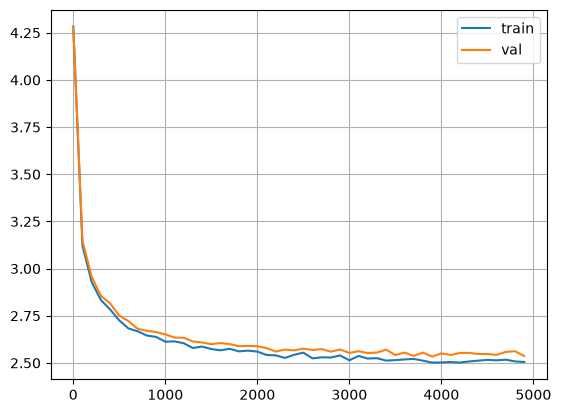

In [179]:
metrics = defaultdict(list)
for i in range(config['num_iters']):
    if i % config['print_every'] == 0:
        loss = estimate_loss(data, model, config)
        metrics['iter'].append(i)
        metrics['train_loss'].append(loss['train'])
        metrics['val_loss'].append(loss['val'])
    X, y = make_batch(data['train'], config)
    logits, batch_loss = model(X, y)

    optim.zero_grad()
    batch_loss.backward()
    optim.step()

plt.plot(metrics['iter'], metrics['train_loss'], label='train')
plt.plot(metrics['iter'], metrics['val_loss'], label='val')
plt.grid(); plt.legend();